# The McNamara Fallacy in Security Metrics

During the Vietnam War, Robert McNamara measured success by body counts because they were easy to count. The U.S. was "winning" by every measurable metric while losing the war. Security dashboards do the same thing: we count vulnerabilities, track patch percentages, and report mean time to detect — but the metrics that actually predict breaches are often the ones we never measure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from decision_security.synth import make_rng, sample

rng = make_rng(42)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PRIMARY = "#1A1A1A"
ACCENT = "#E74C3C"
DARK_BG = "#34495E"
LIGHT_GRAY = "#95A5A6"
MED_GRAY = "#7F8C8D"
VERY_LIGHT = "#BDC3C7"

## 1. Easy Metrics vs Important Metrics

There are two types of security metrics: those that are easy to collect (vulnerability counts, training completion rates, ticket closure times) and those that actually predict outcomes (control coverage gaps, configuration drift velocity, access privilege sprawl rate). The McNamara Fallacy is measuring the first type and treating it as though it were the second.

In [2]:
n_orgs = 50

breach_propensity = rng.beta(2, 8, n_orgs)
breached = rng.binomial(1, breach_propensity)

easy_metrics = {
    "vuln_count": rng.poisson(120, n_orgs),
    "patch_pct": rng.beta(7, 3, n_orgs),
    "training_completion": rng.beta(8, 2, n_orgs),
    "tickets_closed": rng.poisson(45, n_orgs),
    "scan_frequency": rng.choice([1, 2, 4, 12], n_orgs),
    "policies_documented": rng.poisson(15, n_orgs),
    "incidents_reported": rng.poisson(8, n_orgs),
}

hard_metrics = {
    "config_drift_rate": 0.3 * breach_propensity + 0.1 * rng.random(n_orgs),
    "priv_access_ratio": 0.2 + 0.5 * breach_propensity + 0.1 * rng.random(n_orgs),
    "coverage_gap_pct": 0.1 + 0.6 * breach_propensity + 0.1 * rng.random(n_orgs),
}

df = pd.DataFrame({**easy_metrics, **hard_metrics, "breached": breached})

correlations = df.corr()["breached"].drop("breached").sort_values(key=abs, ascending=False)
print("Correlation with breach outcome:")
print(correlations.to_string())

Correlation with breach outcome:
config_drift_rate      0.295100
tickets_closed         0.279216
vuln_count             0.259093
priv_access_ratio      0.204605
scan_frequency        -0.157521
incidents_reported    -0.156470
training_completion    0.127237
coverage_gap_pct       0.120966
policies_documented   -0.028028
patch_pct              0.004285


## 2. Predictive Power Visualization

The bar chart below sorts all metrics by their absolute correlation with breach
outcomes and color-codes them by measurement difficulty. The pattern is not
accidental: hard-to-measure metrics (configuration drift, privilege sprawl,
coverage gaps) carry more signal precisely because they track the causal
mechanisms of compromise, not the activity proxies that are convenient to report.

Easy metrics persist on dashboards because they are cheap to collect, not
because they predict anything.

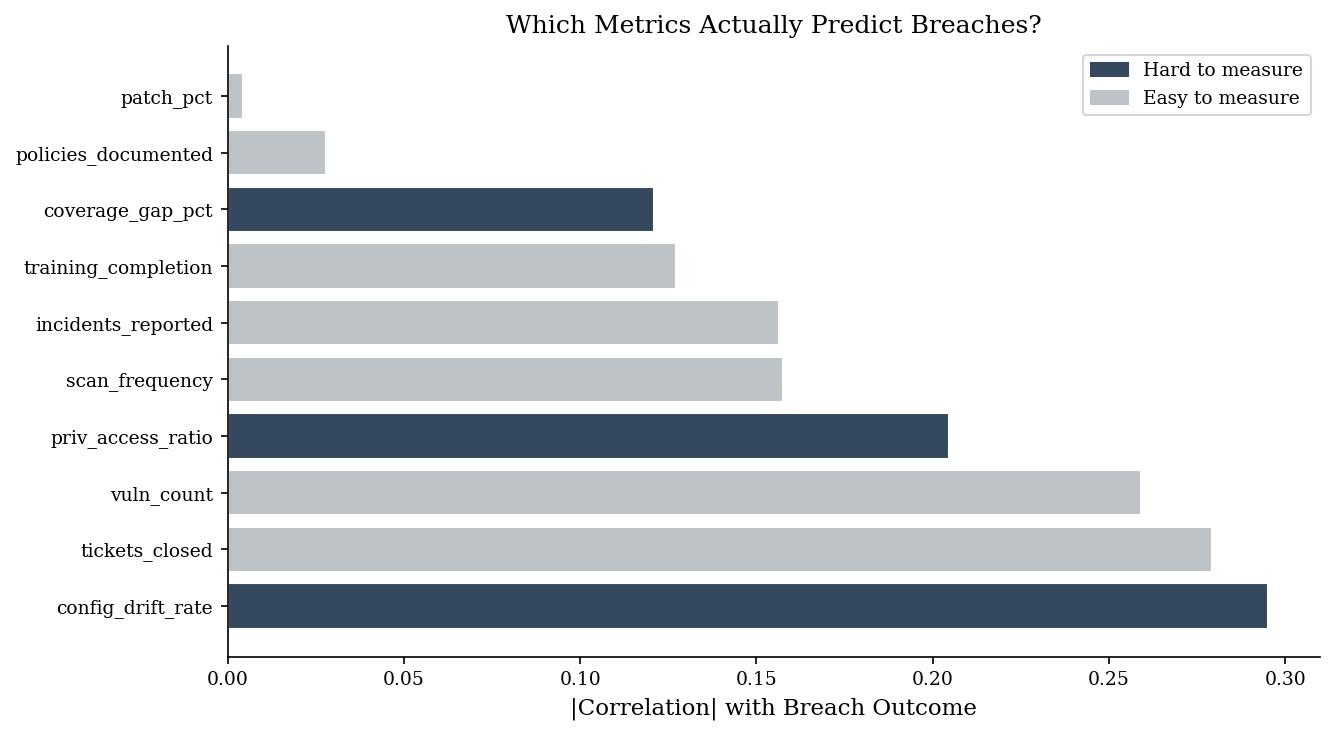

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = [DARK_BG if m in hard_metrics else VERY_LIGHT for m in correlations.index]
ax.barh(correlations.index, correlations.abs().values, color=colors, edgecolor="white")
ax.set_xlabel("|Correlation| with Breach Outcome")
ax.set_title("Which Metrics Actually Predict Breaches?")

import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color=DARK_BG, label="Hard to measure"),
    mpatches.Patch(color=VERY_LIGHT, label="Easy to measure"),
])
plt.tight_layout()
plt.show()

## 3. Goodhart's Law — When a Measure Becomes a Target

"When a measure becomes a target, it ceases to be a good measure." If you incentivize patch percentage, teams will prioritize easy-to-patch low-severity vulnerabilities over hard-to-patch critical ones. The metric goes up; the risk stays the same (or gets worse).

In [4]:
n_vulns = 200
severity = rng.choice(["critical", "high", "medium", "low"], n_vulns, p=[0.05, 0.15, 0.40, 0.40])
risk_weight = {"critical": 50, "high": 10, "medium": 2, "low": 0.5}
patch_effort = {"critical": 8, "high": 4, "medium": 2, "low": 1}

vulns = pd.DataFrame({
    "severity": severity,
    "risk": [risk_weight[s] for s in severity],
    "effort": [patch_effort[s] for s in severity],
})

capacity = 300

by_severity = vulns.sort_values("risk", ascending=False).copy()
by_severity["cum_effort"] = by_severity["effort"].cumsum()
patched_sev = by_severity[by_severity["cum_effort"] <= capacity]

by_ease = vulns.sort_values("effort", ascending=True).copy()
by_ease["cum_effort"] = by_ease["effort"].cumsum()
patched_ease = by_ease[by_ease["cum_effort"] <= capacity]

print("=== Patch by Severity (risk-optimal) ===")
print(f"  Vulns patched: {len(patched_sev)} / {n_vulns} ({100*len(patched_sev)/n_vulns:.0f}%)")
print(f"  Risk eliminated: {patched_sev['risk'].sum():.0f} / {vulns['risk'].sum():.0f} ({100*patched_sev['risk'].sum()/vulns['risk'].sum():.0f}%)")

print(f"\n=== Patch by Ease (metric-optimal) ===")
print(f"  Vulns patched: {len(patched_ease)} / {n_vulns} ({100*len(patched_ease)/n_vulns:.0f}%)")
print(f"  Risk eliminated: {patched_ease['risk'].sum():.0f} / {vulns['risk'].sum():.0f} ({100*patched_ease['risk'].sum()/vulns['risk'].sum():.0f}%)")

print(f"\nGoodhart's Law: {len(patched_ease)-len(patched_sev)} more vulns patched,")
print(f"but {patched_sev['risk'].sum()-patched_ease['risk'].sum():.0f} more risk units left unaddressed.")

=== Patch by Severity (risk-optimal) ===
  Vulns patched: 112 / 200 (56%)
  Risk eliminated: 648 / 692 (94%)

=== Patch by Ease (metric-optimal) ===
  Vulns patched: 183 / 200 (92%)
  Risk eliminated: 322 / 692 (47%)

Goodhart's Law: 71 more vulns patched,
but 326 more risk units left unaddressed.


## 4. Goodhart Visualization

The side-by-side comparison makes the inversion visible. Patching by ease produces
a higher patch count (the metric looks great) but eliminates less than half the
risk. Patching by severity produces a lower count (the metric looks worse) but
eliminates nearly all the risk that matters.

This is Goodhart's Law in its purest form: the team optimizing for the metric
appears to be outperforming the team optimizing for the outcome. Any incentive
structure tied to patch percentage will drive rational actors toward the
metric-optimal strategy — and away from actual risk reduction.

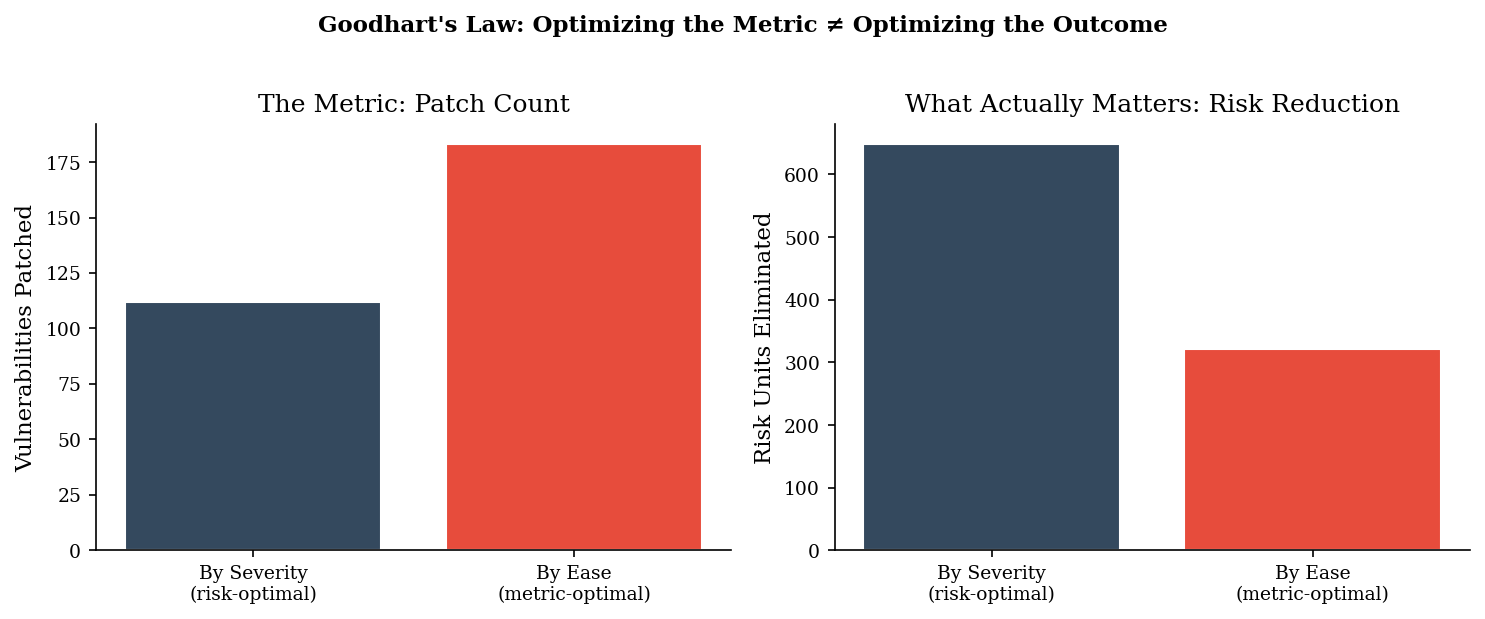

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

strategies = ["By Severity\n(risk-optimal)", "By Ease\n(metric-optimal)"]
patch_counts = [len(patched_sev), len(patched_ease)]
risk_reduced = [patched_sev["risk"].sum(), patched_ease["risk"].sum()]

axes[0].bar(strategies, patch_counts, color=[DARK_BG, ACCENT], edgecolor="white")
axes[0].set_ylabel("Vulnerabilities Patched")
axes[0].set_title("The Metric: Patch Count")

axes[1].bar(strategies, risk_reduced, color=[DARK_BG, ACCENT], edgecolor="white")
axes[1].set_ylabel("Risk Units Eliminated")
axes[1].set_title("What Actually Matters: Risk Reduction")

fig.suptitle("Goodhart's Law: Optimizing the Metric \u2260 Optimizing the Outcome",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 5. Three Questions for Every Metric

Before adding any metric to a dashboard, ask:

1. **So what?** — If this number changes, does it change a decision?
2. **Can it be gamed?** — If someone optimizes this metric directly, does the underlying risk actually improve?
3. **What's the proxy distance?** — How many causal steps lie between this metric and the outcome we care about? The more steps, the weaker the signal.

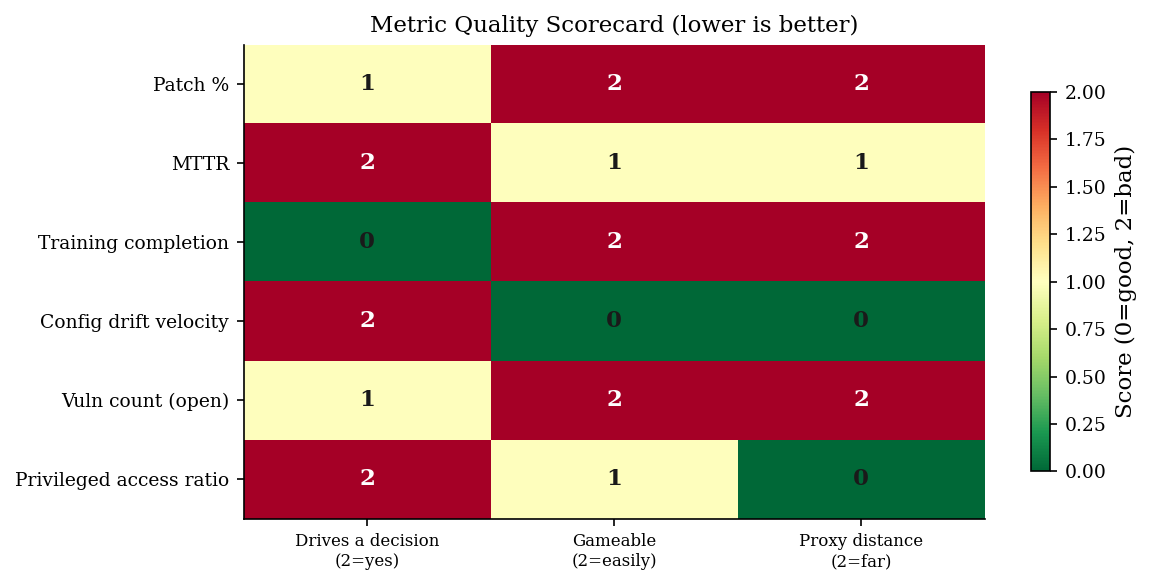

In [6]:
metrics_eval = pd.DataFrame([
    {"metric": "Patch %", "so_what": 1, "gameable": 2, "proxy_distance": 2},
    {"metric": "MTTR", "so_what": 2, "gameable": 1, "proxy_distance": 1},
    {"metric": "Training completion", "so_what": 0, "gameable": 2, "proxy_distance": 2},
    {"metric": "Config drift velocity", "so_what": 2, "gameable": 0, "proxy_distance": 0},
    {"metric": "Vuln count (open)", "so_what": 1, "gameable": 2, "proxy_distance": 2},
    {"metric": "Privileged access ratio", "so_what": 2, "gameable": 1, "proxy_distance": 0},
])

scores = metrics_eval.set_index("metric")[["so_what", "gameable", "proxy_distance"]]
scores.columns = ["Drives a decision\n(2=yes)", "Gameable\n(2=easily)", "Proxy distance\n(2=far)"]

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(scores.values, cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=2)
ax.set_xticks(range(3))
ax.set_xticklabels(scores.columns, fontsize=8)
ax.set_yticks(range(len(scores)))
ax.set_yticklabels(scores.index, fontsize=9)

for i in range(len(scores)):
    for j in range(3):
        ax.text(j, i, str(scores.values[i, j]), ha="center", va="center",
                fontsize=11, fontweight="bold",
                color="white" if scores.values[i, j] > 1 else PRIMARY)

ax.set_title("Metric Quality Scorecard (lower is better)", fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.8, label="Score (0=good, 2=bad)")
plt.tight_layout()
plt.show()

## 6. Pitfalls

- **Volume metrics are almost always McNamara metrics.** Vulnerability counts, alert counts, ticket counts — they measure activity, not security. A team that closes 500 low-severity tickets while ignoring 3 critical ones looks great on the dashboard.
- **"We reduced MTTR by 40%"** means nothing without knowing what changed. Did you get faster at responding, or did you redefine what counts as an incident? Goodhart's Law applies to process metrics too.
- **The hardest metrics to collect are usually the most informative.** Configuration drift, privilege sprawl, control coverage gaps — these require engineering effort to measure, which is exactly why they haven't been gamed yet.
- **Dashboards that optimize for green create incentives against honesty.** If reporting a risk as "red" creates work and reporting it as "green" doesn't, the rational response is to find reasons it's green.